<a href="https://colab.research.google.com/github/harunsy/LogisticRegression.ipynb/blob/main/Klasifikasi_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Praktik: Klasifikasi Data dengan Support Vector Machine (SVM)

## Nama  Kelompok:

*   [24523225 Harunsyah]
*   [24523272 Muhammad Ali Kadir]



## 1. Pilih Dataset Klasifikasi

Sebagai contoh awal, kita akan menggunakan dataset Iris yang tersedia di `sklearn`. Dataset ini adalah dataset klasifikasi klasik yang berisi pengukuran bunga Iris dari tiga spesies berbeda. Tujuan kita adalah mengklasifikasikan spesies bunga berdasarkan pengukuran ini.

**Sumber Dataset:** Dataset Iris tersedia secara built-in di library `sklearn`.

In [15]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame for easier manipulation
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# Add the target variable (species)
df['species'] = iris.target

# Display the first 5 rows of the DataFrame
print("First 5 rows of the Iris dataset:")
display(df.head())

First 5 rows of the Iris dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [16]:
# Display basic information about the dataset
print("\nInformation about the dataset:")
df.info()


Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


## 2. Preprocessing Data

Berdasarkan informasi dataset, tidak ada *missing values* yang perlu ditangani dan semua fitur bersifat numerik, sehingga tidak memerlukan *encoding* untuk fitur. Untuk target variabel `species`, kita akan memetakan nilai numerik (0, 1, 2) ke nama spesies aslinya untuk keterbacaan yang lebih baik. Selanjutnya, kita akan melakukan *scaling* data menggunakan `StandardScaler`.

In [17]:
from sklearn.preprocessing import StandardScaler

# Map numerical species to their actual names
species_mapping = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species_name'] = df['species'].map(species_mapping)

# Separate features (X) and target (y)
X = df.drop(['species', 'species_name'], axis=1)
y = df['species']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Create a DataFrame for scaled features (optional, for better viewing)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("First 5 rows of scaled features:")
display(X_scaled_df.head())
print("\nUnique species names:", df['species_name'].unique())

First 5 rows of scaled features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444



Unique species names: ['setosa' 'versicolor' 'virginica']


## 3. Split Data

Kita akan membagi data menjadi set pelatihan (training set) dan set pengujian (testing set). Set pelatihan akan digunakan untuk melatih model SVM, sedangkan set pengujian akan digunakan untuk mengevaluasi kinerja model. Pembagian ini penting untuk memastikan model dapat digeneralisasi dengan baik ke data baru dan untuk mendeteksi potensi *overfitting*.

In [18]:
from sklearn.model_selection import train_test_split

# Split the scaled data into training and testing sets
# We'll use a test size of 30% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (105, 4)
Shape of X_test: (45, 4)
Shape of y_train: (105,)
Shape of y_test: (45,)


## 4. Modeling SVM

Sekarang kita akan membuat model Support Vector Machine (SVM) menggunakan data yang telah diproses. Untuk dataset Iris, kernel Radial Basis Function (RBF) seringkali merupakan pilihan yang baik karena kemampuannya untuk menangani batas keputusan yang tidak linear, yang mungkin ada dalam data.

In [19]:
from sklearn.svm import SVC

# Initialize the SVM classifier with an RBF kernel
# C is the regularization parameter. A smaller C means stronger regularization.
# gamma defines how far the influence of a single training example reaches.
svm_model = SVC(kernel='rbf', random_state=42)

# Train the model using the training data
svm_model.fit(X_train, y_train)

print("SVM model (RBF kernel) trained successfully!")

SVM model (RBF kernel) trained successfully!


## 5. Evaluasi Model

Setelah model dilatih, langkah selanjutnya adalah mengevaluasi kinerjanya menggunakan data pengujian (test set). Kita akan menghitung metrik umum seperti Accuracy, Precision, Recall, dan F1-Score. Dari hasil ini, kita dapat menganalisis apakah model mengalami *overfitting* atau *underfitting*.

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted') # Use 'weighted' for multi-class
recall = recall_score(y_test, y_pred, average='weighted')     # Use 'weighted' for multi-class
f1 = f1_score(y_test, y_pred, average='weighted')             # Use 'weighted' for multi-class

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Quick analysis for overfitting/underfitting (based on common thresholds)
print("\n--- Analisis Singkat ---")
if accuracy > 0.95:
    print("Model menunjukkan akurasi yang sangat baik. Periksa potensi overfitting jika data training dan test memiliki distribusi yang sangat berbeda.")
elif accuracy < 0.7:
    print("Model mungkin mengalami underfitting. Pertimbangkan untuk menyesuaikan parameter model atau menggunakan model yang lebih kompleks.")
else:
    print("Model memiliki kinerja yang baik. Lakukan analisis lebih lanjut dengan melihat confusion matrix dan metrik per kelas.")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

--- Analisis Singkat ---
Model menunjukkan akurasi yang sangat baik. Periksa potensi overfitting jika data training dan test memiliki distribusi yang sangat berbeda.


## 6. Visualisasi

Untuk lebih memahami kinerja model dan karakteristik dataset, kita akan membuat dua visualisasi:
1.  **Distribusi Kelas:** Memvisualisasikan jumlah sampel untuk setiap spesies dalam dataset.
2.  **Confusion Matrix:** Memvisualisasikan kinerja model dalam mengklasifikasikan setiap kelas, menunjukkan jumlah *true positives, true negatives, false positives,* dan *false negatives*.

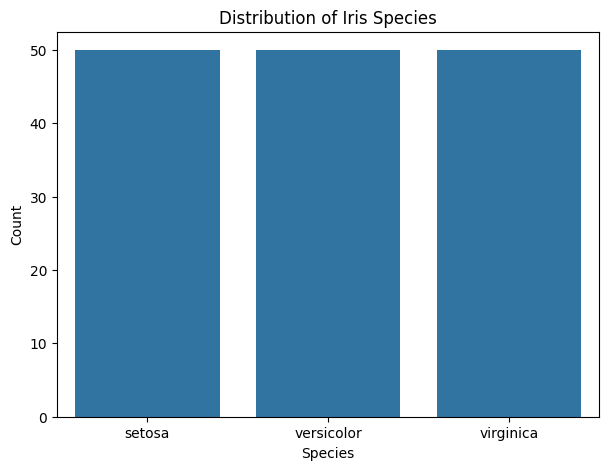

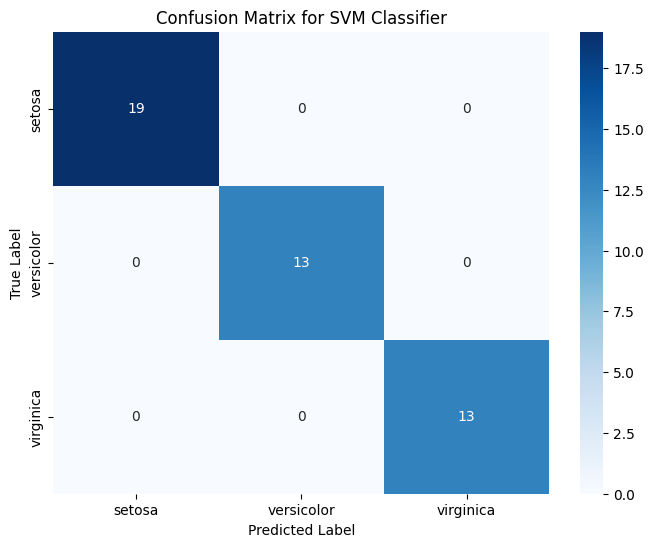

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Visualisasi Distribusi Kelas
plt.figure(figsize=(7, 5))
sns.countplot(x='species_name', data=df)
plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

# 2. Visualisasi Confusion Matrix
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class names from the mapping (ordered by numerical label 0, 1, 2)
class_names = [species_mapping[i] for i in sorted(species_mapping.keys())]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for SVM Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()